In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os
os.environ["OMP_NUM_THREADS"] = "3" # żeby KMeans nie miał wycieków pamięci

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from utils import load_set, load_fitted_models, load_calibrated_models
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import pickle

In [25]:
LR, XGB = load_fitted_models()
X_train, y_train = load_set(r'data\df_train_cleaned.csv', with_FS = True)
X_test, y_test = load_set(r'data\df_test_cleaned.csv', with_FS = True)
X_cal, y_cal = load_set(r'data\df_cal_cleaned.csv', with_FS = True)
models = [LR, XGB]
names = ["Regresja logistyczna", "XGBoost"]

In [26]:
def calibration_diagnostics(y_true, y_pred_proba, n_bins=10, title_prefix="Model"):
    """
    Diagnostyka kalibracji modelu binarnego.
    
    Parametry:
    -----------
    y_true : array-like
        Rzeczywiste etykiety (0/1)
    y_pred_proba : array-like
        Prognozowane prawdopodobieństwa klasy pozytywnej
    n_bins : int
        Liczba przedziałów dla krzywej kalibracji i histogramu
    title_prefix : str
        Prefiks do tytułów wykresów
    """

    # --- Krzywa kalibracji ---
    prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins, strategy='quantile')

    # --- Brier score ---
    brier = brier_score_loss(y_true, y_pred_proba)

    # --- ECA / ACE ---
    bin_edges = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_pred_proba, bin_edges) - 1

    bin_true = np.array([y_true[binids == i].mean() if np.any(binids == i) else np.nan
                         for i in range(n_bins)])
    bin_pred = np.array([y_pred_proba[binids == i].mean() if np.any(binids == i) else np.nan
                         for i in range(n_bins)])
    bin_count = np.array([np.sum(binids == i) for i in range(n_bins)])
    weights = bin_count / np.sum(bin_count)

    valid = ~np.isnan(bin_true)
    ece = np.sum(weights[valid] * np.abs(bin_true[valid] - bin_pred[valid]))  # Expected Calibration Error
    ace = np.nanmean(np.abs(bin_true[valid] - bin_pred[valid]))               # Absolute Calibration Error

    # --- Wykresy ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Krzywa kalibracji
    ax[0].plot([0, 1], [0, 1], 'k--', label='Ideal')
    ax[0].plot(prob_pred, prob_true, marker='o', label='Empirical')
    ax[0].set_xlabel("Średnie przewidziane prawdopodobieństwo")
    ax[0].set_ylabel("Rzeczywista częstość pozytywów")
    ax[0].set_title(f"{title_prefix} – Krzywa kalibracji")
    ax[0].legend()
    ax[0].grid(True)

    # 2. Histogram predykcji
    ax[1].hist(y_pred_proba, bins=20, color='skyblue', edgecolor='black')
    ax[1].set_xlabel("Prognozowane prawdopodobieństwo")
    ax[1].set_ylabel("Liczba obserwacji")
    ax[1].set_title(f"{title_prefix} – Histogram predykcji")

    plt.tight_layout()
    plt.show()

    # --- Wyniki ---
    print(f"🔍 Diagnostyka kalibracji – {title_prefix}")
    print(f"Brier score: {brier:.5f}")
    print(f"ECE (Expected Calibration Error): {ece:.5f}")
    print(f"ACE (Absolute Calibration Error): {ace:.5f}")


## Diagnostyka "pre-cal"

####################
Regresja logistyczna


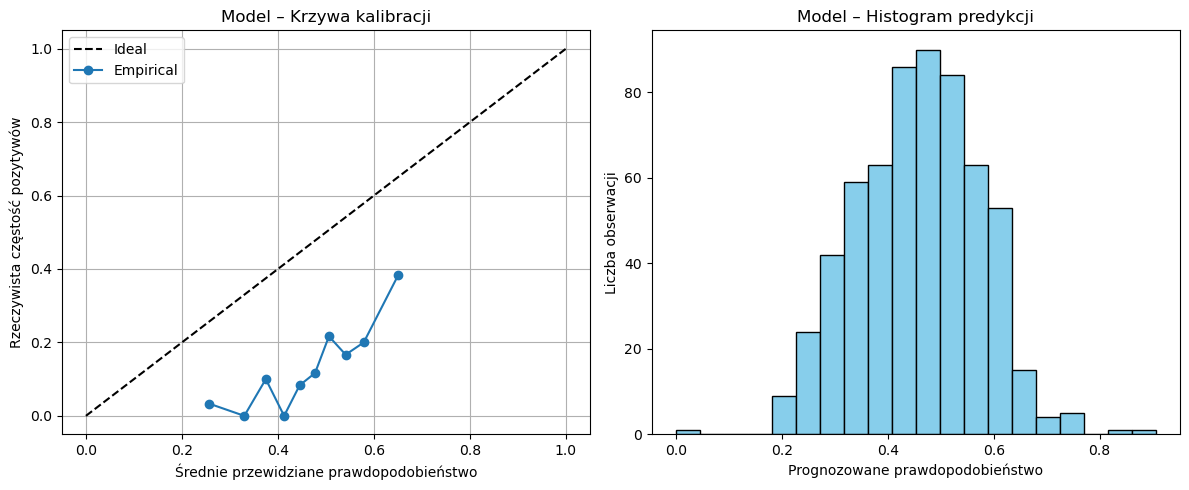

🔍 Diagnostyka kalibracji – Model
Brier score: 0.21083
ECE (Expected Calibration Error): 0.33157
ACE (Absolute Calibration Error): 0.32055
####################
XGBoost


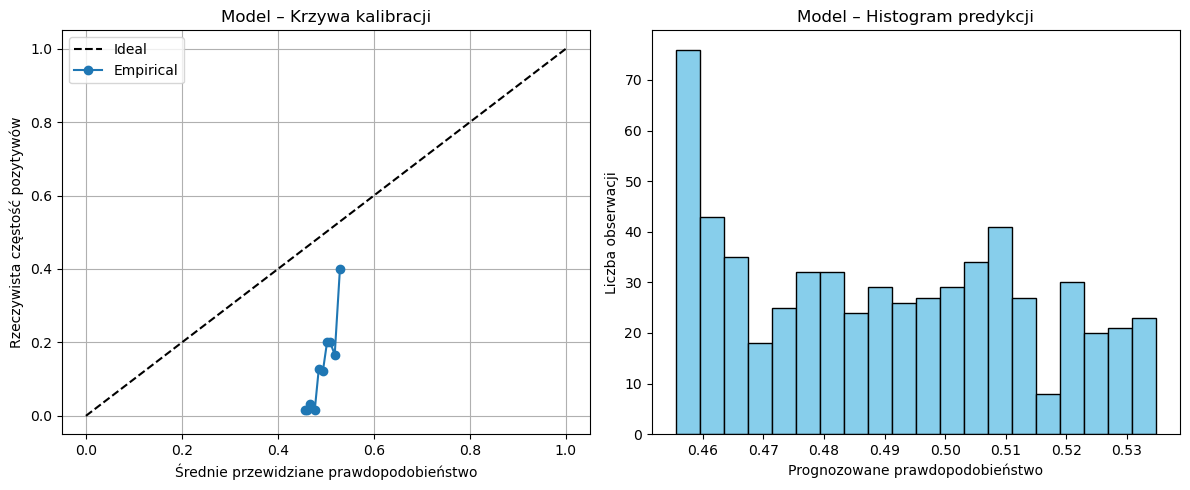

🔍 Diagnostyka kalibracji – Model
Brier score: 0.23822
ECE (Expected Calibration Error): 0.35986
ACE (Absolute Calibration Error): 0.34428


In [27]:
for model, name in zip(models, names):
    print('#'*20)
    print(name)
    calibration_diagnostics(y_test, model.predict_proba(X_test)[:,1])

In [28]:
calibrated_LR = CalibratedClassifierCV(FrozenEstimator(LR), method='sigmoid', cv=5, ensemble=False)
calibrated_LR.fit(X_cal, y_cal)
calibrated_XGB = CalibratedClassifierCV(FrozenEstimator(XGB), method='sigmoid', cv=5)
calibrated_XGB.fit(X_cal, y_cal)

,estimator,"FrozenEstimat...ee=None, ...))"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,0.6381063823097928
,colsample_bynode,0.6638152165342569


In [29]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

def logit(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def calibrate_in_the_large(p_pred, target=0.04, tol=1e-9, max_iter=200):
    """
    Dopasowuje jedynie intercept (delta), aby średnia predykcji ≈ target.
    Zwraca (p_calibrated, delta)
    """
    logits = logit(np.asarray(p_pred))

    def mean_diff(delta):
        return float(np.mean(logistic(logits + delta)) - target)

    # bisekcja w bezpiecznych granicach
    lo, hi = -50, 50
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        f_mid = mean_diff(mid)
        if abs(f_mid) < tol:
            return logistic(logits + mid), mid
        if mean_diff(lo) * f_mid <= 0:
            hi = mid
        else:
            lo = mid
    return logistic(logits + mid), mid


In [30]:
# LR
p_LR = calibrated_LR.predict_proba(X_cal)[:, 1]
p_LR_adj, delta_LR = calibrate_in_the_large(p_LR, target=0.04)
print("LR: delta =", delta_LR, "średnia PD po:", np.mean(p_LR_adj))

# XGB
p_XGB = calibrated_XGB.predict_proba(X_cal)[:, 1]
p_XGB_adj, delta_XGB = calibrate_in_the_large(p_XGB, target=0.04)
print("XGB: delta =", delta_XGB, "średnia PD po:", np.mean(p_XGB_adj))

LR: delta = -1.3393737375736237 średnia PD po: 0.039999999213787815
XGB: delta = -1.363755390048027 średnia PD po: 0.03999999998741243


In [31]:
calibrated_LR.calibrated_classifiers_[0].calibrators[0].b_ -= delta_LR
calibrated_XGB.calibrated_classifiers_[0].calibrators[0].b_ -= delta_XGB

In [32]:
calibrated_LR.predict_proba(X_test)[:,1].mean()

0.038521357364884

## Walidacja "post-cal"

####################
Skalibrowana Regresja Logistyczna


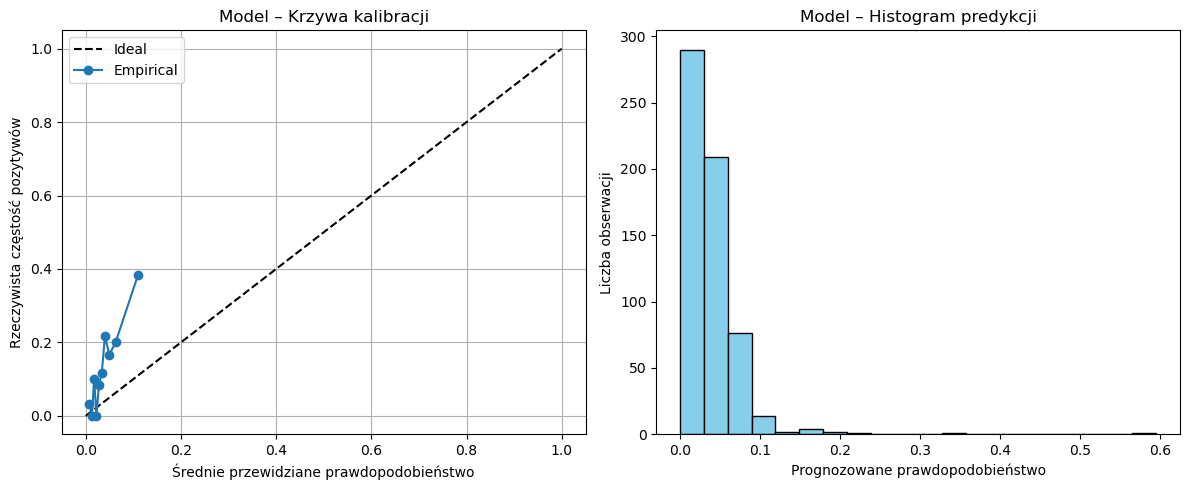

🔍 Diagnostyka kalibracji – Model
Brier score: 0.11455
ECE (Expected Calibration Error): 0.09148
ACE (Absolute Calibration Error): 0.47123
####################
Skalibrowany XGBoost


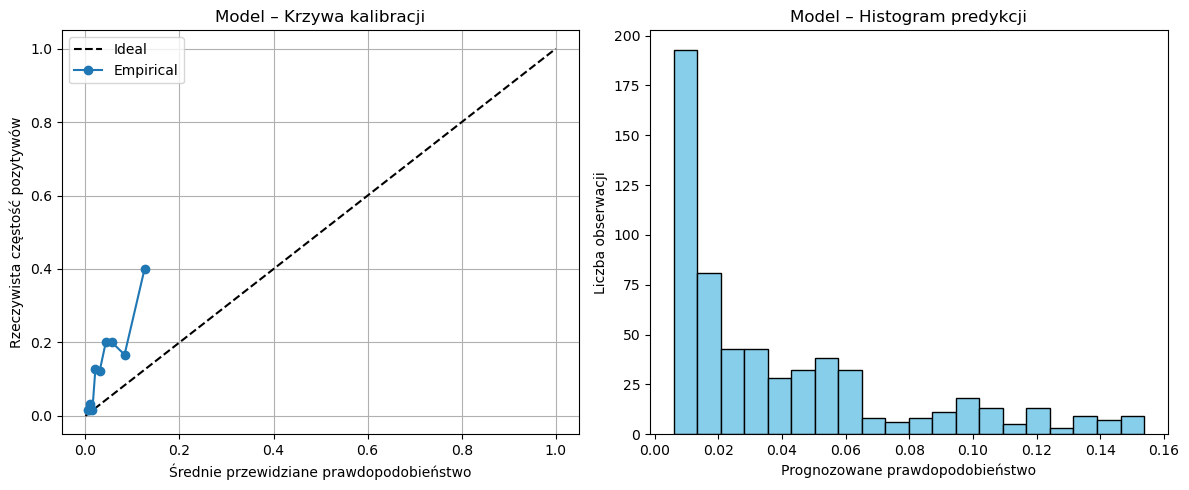

🔍 Diagnostyka kalibracji – Model
Brier score: 0.11443
ECE (Expected Calibration Error): 0.09016
ACE (Absolute Calibration Error): 0.18052


In [33]:
cal_models = [calibrated_LR, calibrated_XGB]
cal_names = ["Skalibrowana Regresja Logistyczna", 'Skalibrowany XGBoost']
for model, name in zip(cal_models, cal_names):
    print('#'*20)
    print(name)
    calibration_diagnostics(y_test, model.predict_proba(X_test)[:,1])

In [34]:
with open("models/CalibratedLogisticRegression.pkl", "wb") as f:
    pickle.dump(calibrated_LR,f)
with open("models/CalibratedXGBoost.pkl", "wb") as f:
    pickle.dump(calibrated_XGB, f)

## Progi decyzyjne i krzywe kosztu

In [35]:
# Wczytanie skalibrowanych modeli
CLR, CXGB = load_calibrated_models()

In [36]:
# Parametry kosztów 
COST_TP =  0.0    # zysk z trafionej pozytywnej decyzji
COST_FP =  1.0    # koszt fałszywie pozytywnej
COST_FN =  5.0    # koszt fałszywie negatywnej
COST_TN =  0.0    

def cost_for_threshold(y_true, p, thr):
    yhat = (p >= thr).astype(int)
    tp = np.sum((yhat==1) & (y_true==1))
    fp = np.sum((yhat==1) & (y_true==0))
    fn = np.sum((yhat==0) & (y_true==1))
    tn = np.sum((yhat==0) & (y_true==0))
    return tp*COST_TP + fp*COST_FP + fn*COST_FN + tn*COST_TN, tp, fp, fn, tn

def sweep_costs(y_true, p, n=101):
    thrs = np.linspace(0,1,n)
    costs, details = [], []
    for t in thrs:
        c, tp, fp, fn, tn = cost_for_threshold(y_true, p, t)
        costs.append(c); details.append((tp,fp,fn,tn))
    return thrs, np.array(costs), details

def plot_cost_curve(y_te, p_adj, model_name="Model"):
    thrs, costs, details = sweep_costs(y_te, p_adj, n=201)
    best_idx = int(np.argmin(costs))
    best_thr = float(thrs[best_idx])
    best_tp, best_fp, best_fn, best_tn = details[best_idx]
    
    plt.figure()
    plt.plot(thrs, costs)
    plt.title(f"{model_name} - Krzywa kosztu vs próg")
    plt.xlabel("Próg")
    plt.ylabel("Koszt (niżej lepiej)")
    plt.show()

    print(f"Podsumowanie dla {model_name}:")
    print("Najlepszy próg:", best_thr)
    print(f"TP: {best_tp}, FP: {best_fp}, FN: {best_fn}, TN: {best_tn}")
    # Czy to nie jest stopa odrzucenia?
    accept_rate = (best_tp + best_fp) / len(y_te)
    print("Stopa akceptacji:", round(accept_rate, 4))

In [37]:
# LR
p_test_CLR = CLR.predict_proba(X_test)[:, 1]


# XGB
p_test_CXGB = CXGB.predict_proba(X_test)[:, 1]

# Dla utrzymania porządku 
calibrated_models = [CLR, CXGB]
calibrated_model_names = ["Skalibrowana Regresja Logistyczna", 'Skalibrowany XGBoost']
probs_cal = [p_test_CLR, p_test_CXGB]

### Krzywe kosztu po kalibracji

##################################################
Skalibrowana Regresja Logistyczna


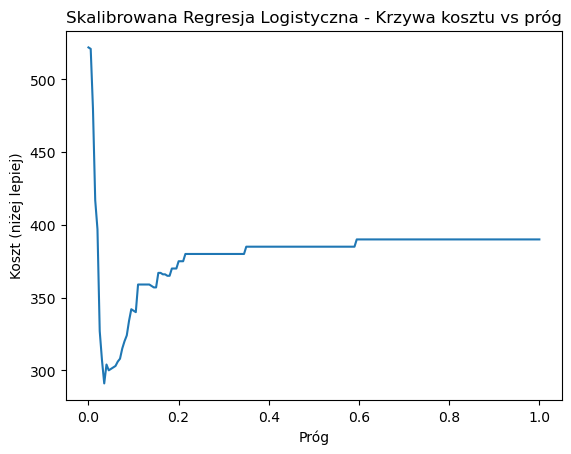

Podsumowanie dla Skalibrowana Regresja Logistyczna:
Najlepszy próg: 0.035
TP: 60, FP: 201, FN: 18, TN: 321
Stopa akceptacji: 0.435
##################################################
Skalibrowany XGBoost


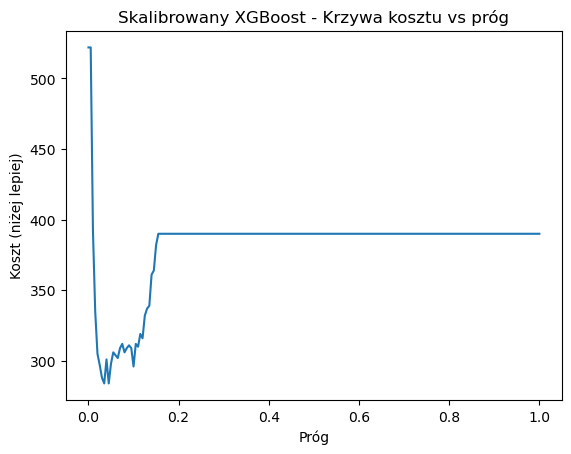

Podsumowanie dla Skalibrowany XGBoost:
Najlepszy próg: 0.035
TP: 58, FP: 184, FN: 20, TN: 338
Stopa akceptacji: 0.4033


In [38]:
for model, name, p in zip(calibrated_models, calibrated_model_names, probs_cal):
    print('#'*50)
    print(name)
    plot_cost_curve(y_test, p, name)

## Symulacja wpływu macierzy kosztów na krzywą i próg odcięcia
Oznaczenia:
- COST_TP = zysk z trafionej pozytywnej decyzji (poprawne odrzucenie),
- COST_FP = koszt fałszywie pozytywnej (fałszywy alarm = utracony klient),
- COST_TN = zysk z trafionej negatywnej decyzji (poprawne przyjęcie),
- COST_FN = koszt fałszywie negatywnej (niewykrycie defaultu = przyjęty ryzykowny klient).

#### Jak czytać wykres analizy wrażliwości?
Ten wykres z dwiema osiami (niebieską i pomarańczową) opowiada historię "co by było, gdybyśmy bali się ryzyka bardziej lub mniej".

---
- Oś X (Pozioma) - "Wskaźnik Strachu":
    - To jest FN_Cost_Ratio.
    - Wartość 5 oznacza: "Strata na jednym bankrucie boli nas tak samo jak utrata 5 dobrych klientów".
    - Wartość 20 oznacza: "Jeden bankrut to katastrofa, musimy znaleźć 20 dobrych klientów, żeby odrobić tę stratę".
    - Użycie: Wybierz punkt na tej osi, który pasuje do danego biznesu (np. dla firm korporacyjnych celuj w okolice 10-15, dla chwilówek w okolice 3-5).
---
- Oś Y Lewa (Niebieska linia) - "Szlaban":
    - Pokazuje Optymalny Próg (Threshold).
    - Im bardziej w prawo (im większy koszt ryzyka), tym niebieska linia spada.
    - Jeśli ryzyko jest drogie, musisz obniżać próg (być bardziej restrykcyjnym), żeby wpuszczać tylko najpewniejszych.
---
- Oś Y Prawa (Pomarańczowa linia) - "Kurek z pieniędzmi":
    - Pokazuje Stopę Akceptacji.
    - Ona też spada wraz z przesuwaniem się w prawo.
    - To pokazuje cenę bezpieczeństwa: "Chcesz mieć super bezpieczny portfel (wysoki ratio)? To przygotuj się, że odrzucisz 90% wniosków (niska linia pomarańczowa)".

MODEL: Skalibrowana Regresja Logistyczna
Rozpoczynam symulację scenariuszy kosztowych...
=== STRATEGIA MAX F1-SCORE ===
Najlepszy próg (Data Science): 0.0369
Maksymalny F1-Score: 0.3676
------------------------------
IMPLIKACJE BIZNESOWE:
-> Stopa Akceptacji: 59.50%
-> Default Rate w Portfelu: 5.32%


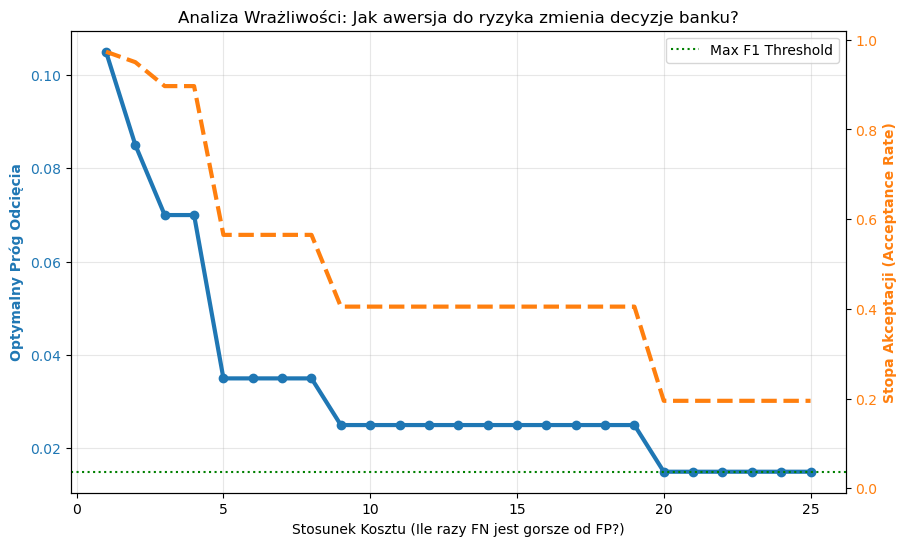

,FN_Cost_Ratio,Optimal_Threshold,Acceptance_Rate,Portfolio_Bad_Rate,Total_Cost
0,1.0,0.105,0.973333,0.114726,72.0
1,2.0,0.085,0.950000,0.108772,138.0
2,3.0,0.070,0.896667,0.100372,200.0
3,4.0,0.070,0.896667,0.100372,254.0
4,5.0,0.035,0.565000,0.053097,291.0


PRZYPADEK 1: Podejście optymistyczne
=== REKOMENDACJA DLA KOSZTU FN/FP = 5.0 ===
Znaleziono najbliższy symulowany punkt: 5.00
----------------------------------------
1. Ustaw PRÓG ODCIĘCIA (Threshold) na:  0.0350
2. Spodziewana STOPA AKCEPTACJI:          56.50%
3. Przewidywany BAD RATE w portfelu:      5.31%
----------------------------------------
PRZYPADEK 2: Podejście konserwatywne
=== REKOMENDACJA DLA KOSZTU FN/FP = 12.0 ===
Znaleziono najbliższy symulowany punkt: 12.00
----------------------------------------
1. Ustaw PRÓG ODCIĘCIA (Threshold) na:  0.0250
2. Spodziewana STOPA AKCEPTACJI:          40.50%
3. Przewidywany BAD RATE w portfelu:      3.29%
----------------------------------------


MODEL: Skalibrowany XGBoost
Rozpoczynam symulację scenariuszy kosztowych...
=== STRATEGIA MAX F1-SCORE ===
Najlepszy próg (Data Science): 0.1014
Maksymalny F1-Score: 0.3714
------------------------------
IMPLIKACJE BIZNESOWE:
-> Stopa Akceptacji: 89.67%
-> Default Rate w Portfelu: 9.67%


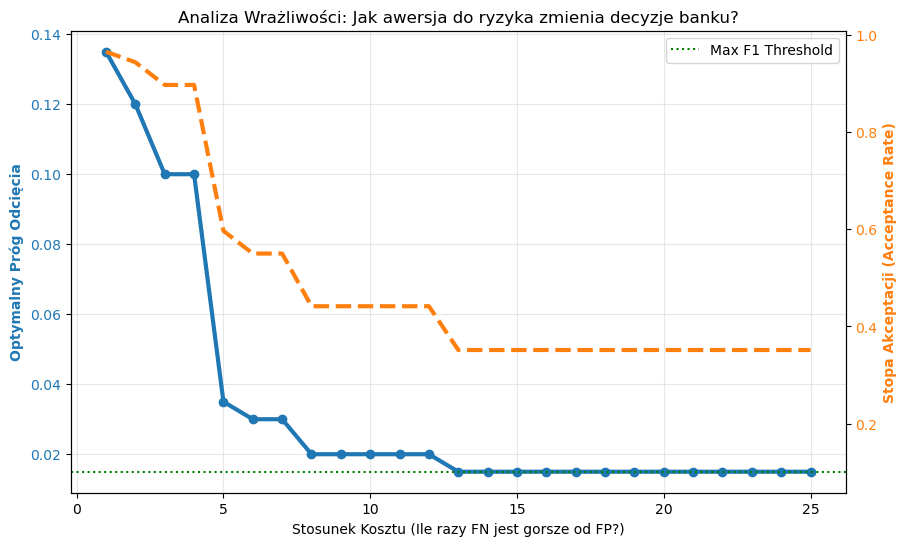

,FN_Cost_Ratio,Optimal_Threshold,Acceptance_Rate,Portfolio_Bad_Rate,Total_Cost
0,1.0,0.135,0.965000,0.113990,75.0
1,2.0,0.120,0.943333,0.106007,136.0
2,3.0,0.100,0.896667,0.096654,192.0
3,4.0,0.100,0.896667,0.096654,244.0
4,5.0,0.035,0.596667,0.055866,284.0


PRZYPADEK 1: Podejście optymistyczne
=== REKOMENDACJA DLA KOSZTU FN/FP = 5.0 ===
Znaleziono najbliższy symulowany punkt: 5.00
----------------------------------------
1. Ustaw PRÓG ODCIĘCIA (Threshold) na:  0.0350
2. Spodziewana STOPA AKCEPTACJI:          59.67%
3. Przewidywany BAD RATE w portfelu:      5.59%
----------------------------------------
PRZYPADEK 2: Podejście konserwatywne
=== REKOMENDACJA DLA KOSZTU FN/FP = 12.0 ===
Znaleziono najbliższy symulowany punkt: 12.00
----------------------------------------
1. Ustaw PRÓG ODCIĘCIA (Threshold) na:  0.0200
2. Spodziewana STOPA AKCEPTACJI:          44.17%
3. Przewidywany BAD RATE w portfelu:      3.02%
----------------------------------------




In [39]:
# Funkcje pomocnicze (z lekką optymalizacją pod symulację)
def get_optimal_threshold(y_true, p_proba, cost_fn, cost_fp=1.0, cost_tp=0.0, cost_tn=0.0, n_steps=201):
    """
    Znajduje jeden optymalny próg dla konkretnej kombinacji kosztów.
    """
    thresholds = np.linspace(0, 1, n_steps)
    costs = []
    
    # Dla każdego progu liczymy koszt
    # Koszt całkowity = FP*Cost_FP + FN*Cost_FN
    # (TP i TN mają koszt 0 lub ujemny jako zysk, tu upraszczamy do kosztów błędów)
    
    for thr in thresholds:
        y_pred = (p_proba >= thr).astype(int)
        
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        # Opcjonalnie można dodać zyski z TP/TN, ale zazwyczaj optymalizuje się błędy
        total_cost = (fp * cost_fp) + (fn * cost_fn)
        costs.append(total_cost)
        
    best_idx = np.argmin(costs)
    best_thr = thresholds[best_idx]
    min_cost = costs[best_idx]
    
    # Obliczamy metryki dla tego najlepszego progu
    y_final_pred = (p_proba >= best_thr).astype(int)
    
    # POPRAWKA: y_pred=1 to zazwyczaj 'Default' -> ODRZUCENIE wniosku
    # Akceptacja to y_pred=0
    n_rejected = np.sum(y_final_pred == 1)
    n_accepted = np.sum(y_final_pred == 0)
    
    acceptance_rate = n_accepted / len(y_true)
    
    # Default Rate w portfelu (jakość zaakceptowanych)
    # Ile z zaakceptowanych (0) to faktycznie źli (1)?
    accepted_mask = (y_final_pred == 0)
    if n_accepted > 0:
        portfolio_bad_rate = np.sum(y_true[accepted_mask] == 1) / n_accepted
    else:
        portfolio_bad_rate = 0.0
        
    return {
        'FN_Cost_Ratio': cost_fn / cost_fp, # Ile razy gorszy jest default od utraty klienta
        'Optimal_Threshold': best_thr,
        'Acceptance_Rate': acceptance_rate,
        'Portfolio_Bad_Rate': portfolio_bad_rate,
        'Total_Cost': min_cost
    }

def simulate_business_scenarios(model, X, y, fn_cost_range):
    """
    Symuluje różne scenariusze biznesowe.
    """
    # 1. Pobierz prawdopodobieństwa (dla klasy 1)
    # Zakładam, że model ma metodę predict_proba
    if hasattr(model, "predict_proba"):
        p_proba = model.predict_proba(X)[:, 1]
    else:
        p_proba = model # Jeśli przekazano już wektor prawdopodobieństw
        
    results = []
    
    print("Rozpoczynam symulację scenariuszy kosztowych...")
    for fn_cost in fn_cost_range:
        # Zakładamy FP=1 (koszt utraconej szansy), zmieniamy FN (koszt defaultu)
        res = get_optimal_threshold(y, p_proba, cost_fn=fn_cost, cost_fp=1.0)
        results.append(res)
        
    return pd.DataFrame(results)


from sklearn.metrics import precision_recall_curve

def analyze_max_f1_strategy(y_true, y_proba):
    """
    Znajduje próg maksymalizujący F1-Score i symuluje jego skutki biznesowe.
    """
    # 1. Obliczamy precyzję, czułość i progi (Szybka metoda wektorowa ze sklearn)
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # 2. Liczymy F1 dla każdego punktu krzywej
    # Zabezpieczenie przed dzieleniem przez zero
    numerator = 2 * precisions * recalls
    denominator = precisions + recalls
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(denominator), where=denominator!=0)
    
    # 3. Znajdujemy indeks maksimum
    # (thresholds w sklearn jest krótsze o 1 od precisions/recalls, więc bierzemy odpowiedni indeks)
    best_idx = np.argmax(f1_scores)
    best_thr_f1 = thresholds[best_idx]
    max_f1 = f1_scores[best_idx]
    
    # 4. Przeliczenie na KPI biznesowe dla tego progu
    y_pred_f1 = (y_proba >= best_thr_f1).astype(int)
    
    n_rejected = np.sum(y_pred_f1 == 1)
    n_accepted = np.sum(y_pred_f1 == 0) # Klasa 0 = Akceptacja
    n_total = len(y_true)
    
    acceptance_rate = n_accepted / n_total
    
    # Jakość portfela (ile złych wśród zaakceptowanych)
    if n_accepted > 0:
        bad_in_portfolio = np.sum((y_pred_f1 == 0) & (y_true == 1))
        portfolio_default_rate = bad_in_portfolio / n_accepted
    else:
        portfolio_default_rate = 0.0

    print(f"=== STRATEGIA MAX F1-SCORE ===")
    print(f"Najlepszy próg (Data Science): {best_thr_f1:.4f}")
    print(f"Maksymalny F1-Score: {max_f1:.4f}")
    print("-" * 30)
    print("IMPLIKACJE BIZNESOWE:")
    print(f"-> Stopa Akceptacji: {acceptance_rate:.2%}")
    print(f"-> Default Rate w Portfelu: {portfolio_default_rate:.2%}")
    
    return best_thr_f1

def get_recommendation_for_ratio(df_results, target_ratio):
    """
    Wyciąga dokładne parametry dla zadanego stosunku kosztów (FN/FP).
    """
    # Znajdujemy wiersz z ratio najbliższym temu, którego szukasz
    # (bo w symulacji mamy np. 5.12 a szukamy 5.0)
    closest_idx = (df_results['FN_Cost_Ratio'] - target_ratio).abs().idxmin()
    row = df_results.loc[closest_idx]
    
    print(f"=== REKOMENDACJA DLA KOSZTU FN/FP = {target_ratio} ===")
    print(f"Znaleziono najbliższy symulowany punkt: {row['FN_Cost_Ratio']:.2f}")
    print("-" * 40)
    print(f"1. Ustaw PRÓG ODCIĘCIA (Threshold) na:  {row['Optimal_Threshold']:.4f}")
    print(f"2. Spodziewana STOPA AKCEPTACJI:          {row['Acceptance_Rate']:.2%}")
    print(f"3. Przewidywany BAD RATE w portfelu:      {row['Portfolio_Bad_Rate']:.2%}")
    print("-" * 40)
    return row


# Zdefiniuj zakres kosztów FN (od 1:1 do 25:1)
cost_range = np.linspace(1, 25, 25) 

# Uruchom symulację (zamiast model.predict_proba możesz podać gotowy wektor 'p_adj')
#df_results = simulate_business_scenarios(model, X_test, y_test, cost_range)
# LUB jeśli masz już prawdopodobieństwa w zmiennej p_adj:
for model, name, p in zip(calibrated_models, calibrated_model_names, probs_cal):
    print(f"MODEL: {name}")
    # "Biznesowe optimum" z macierzy kosztów
    df_results = simulate_business_scenarios(p, None, y_test, cost_range)
    # "Matematyczne optimum" z F1 Score 
    best_threshold_f1 = analyze_max_f1_strategy(y_test, p)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    color = 'tab:blue'
    ax1.set_xlabel('Stosunek Kosztu (Ile razy FN jest gorsze od FP?)')
    ax1.set_ylabel('Optymalny Próg Odcięcia', color=color, fontweight='bold')
    ax1.plot(df_results['FN_Cost_Ratio'], df_results['Optimal_Threshold'], color=color, linewidth=3, marker='o')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)
    
    # Druga oś dla Stopy Akceptacji
    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel('Stopa Akceptacji (Acceptance Rate)', color=color, fontweight='bold')
    ax2.plot(df_results['FN_Cost_Ratio'], df_results['Acceptance_Rate'], color=color, linewidth=3, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)
    # Punkt optymalnej metryki F1
    plt.axhline(best_threshold_f1, color='green', linestyle=':', label='Max F1 Threshold')
    plt.legend()
    plt.title('Analiza Wrażliwości: Jak awersja do ryzyka zmienia decyzje banku?')
    plt.show()
    
    display(df_results.head())

    # Przypadek 1: Optymistyczny (np. Kredyty Gotówkowe, wysoka marża)
    # Załóżmy, że strata boli nas 5x bardziej niż utrata klienta
    print("PRZYPADEK 1: Podejście optymistyczne")
    get_recommendation_for_ratio(df_results, target_ratio=5.0)
    
    # Przypadek 2: Konserwatywny (np. Kredyty Firmowe, niska marża)
    # Załóżmy, że strata boli nas 12x bardziej
    print("PRZYPADEK 2: Podejście konserwatywne")
    get_recommendation_for_ratio(df_results, target_ratio=12.0)
    print("\n")

In [40]:
from sklearn.metrics import roc_curve

def analyze_alternative_strategies(y_true, y_proba, cost_ratio=5.0):
    """
    Analizuje alternatywne metody wyznaczania progu dla modelu skalibrowanego.
    cost_ratio = Koszt FN / Koszt FP (np. 5.0)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    
    # --- 1. PODEJŚCIE ANALITYCZNE (Bayes) ---
    # T = 1 / (1 + Ratio)
    # Np. dla Ratio 5:1 -> T = 1/6 = 0.1667
    bayes_thr = 1 / (1 + cost_ratio)
    
    # --- 2. INDEX YOUDENA (Max J) ---
    # J = TPR - FPR
    j_scores = tpr - fpr
    best_idx_j = np.argmax(j_scores)
    youden_thr = thresholds[best_idx_j]
    
    # --- 3. SAFETY FIRST (Cel: Bad Rate <= 1.5%) ---
    # Szukamy progu, przy którym Default Rate w portfelu spada poniżej celu
    # To wymaga iteracji (symulacji), użyjemy prostej pętli po percentylach
    safety_target = 0.015 # Cel: 1.5% szkodowości
    safety_thr = 1.0 # Domyślnie nikogo nie bierzemy
    
    # Sprawdzamy progi od 0 do 1
    for thr in np.linspace(0, 1, 200):
        y_pred = (y_proba >= thr).astype(int)
        # Akceptujemy (0)
        accepted_mask = (y_pred == 0)
        n_accepted = np.sum(accepted_mask)
        
        if n_accepted > 50: # Warunek min. próbki
            real_bad_rate = np.mean(y_true[accepted_mask])
            if real_bad_rate <= safety_target:
                safety_thr = thr
                break # Znaleźliśmy pierwszy próg (od dołu), który jest bezpieczny
    
    # --- WYPISANIE WYNIKÓW ---
    print(f"=== ALTERNATYWNE STRATEGIE ===")
    
    print(f"\n1. PODEJŚCIE ANALITYCZNE (Dla Ratio {cost_ratio}:1)")
    print(f"   (Wynika wprost ze wzoru matematycznego, ignoruje rozkład danych)")
    print(f"   -> Sugerowany Próg: {bayes_thr:.4f}")
    
    print(f"\n2. INDEX YOUDENA (Balans Czułości i Specyficzności)")
    print(f"   (Traktuje błędy równoważnie, maksymalizuje moc dyskryminacyjną)")
    print(f"   -> Sugerowany Próg: {youden_thr:.4f}")
    
    print(f"\n3. SAFETY FIRST (Target Bad Rate <= {safety_target:.1%})")
    print(f"   (Biznesowe ograniczenie ryzyka portfela)")
    print(f"   -> Sugerowany Próg: {safety_thr:.4f}")
    
    return bayes_thr, youden_thr, safety_thr

# Użycie (podstaw ratio, które wybrałeś wcześniej, np. 5.0 lub 11.0)
for model, name, p in zip(calibrated_models, calibrated_model_names, probs_cal):
    print(f"MODEL: {name}")
    bayes_t, youden_t, safety_t = analyze_alternative_strategies(y_test, p, cost_ratio=5)
    print()

MODEL: Skalibrowana Regresja Logistyczna
=== ALTERNATYWNE STRATEGIE ===

1. PODEJŚCIE ANALITYCZNE (Dla Ratio 5:1)
   (Wynika wprost ze wzoru matematycznego, ignoruje rozkład danych)
   -> Sugerowany Próg: 0.1667

2. INDEX YOUDENA (Balans Czułości i Specyficzności)
   (Traktuje błędy równoważnie, maksymalizuje moc dyskryminacyjną)
   -> Sugerowany Próg: 0.0369

3. SAFETY FIRST (Target Bad Rate <= 1.5%)
   (Biznesowe ograniczenie ryzyka portfela)
   -> Sugerowany Próg: 1.0000

MODEL: Skalibrowany XGBoost
=== ALTERNATYWNE STRATEGIE ===

1. PODEJŚCIE ANALITYCZNE (Dla Ratio 5:1)
   (Wynika wprost ze wzoru matematycznego, ignoruje rozkład danych)
   -> Sugerowany Próg: 0.1667

2. INDEX YOUDENA (Balans Czułości i Specyficzności)
   (Traktuje błędy równoważnie, maksymalizuje moc dyskryminacyjną)
   -> Sugerowany Próg: 0.0295

3. SAFETY FIRST (Target Bad Rate <= 1.5%)
   (Biznesowe ograniczenie ryzyka portfela)
   -> Sugerowany Próg: 1.0000



## Mapowanie PD → klasy ratingowe (AAA, …, C)

In [41]:
from sklearn.cluster import KMeans

def get_optimal_rating_bins(y_proba, n_classes=9):
    """
    Generuje optymalne progi ratingowe na podstawie wektora prawdopodobieństw (PD).
    Używa klasteryzacji KMeans do znalezienia naturalnych grup ryzyka.
    """
    # 1. Trenujemy KMeans na wektorze prawdopodobieństw
    # reshape(-1, 1) jest wymagane, bo to jedna cecha
    kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=20)
    kmeans.fit(y_proba.reshape(-1, 1))
    
    # 2. Pobieramy predykcje klastrów dla każdego punktu, aby znaleźć granice
    df_temp = pd.DataFrame({'proba': y_proba, 'cluster': kmeans.labels_})
    
    # 3. Dla każdego klastra znajdujemy jego maksymalną wartość PD
    # To będą nasze punkty odcięcia (thresholds)
    cluster_maxs = df_temp.groupby('cluster')['proba'].max().sort_values().values
    
    # 4. Tworzymy listę progów
    # Zaczynamy od 0.0, dodajemy maxy klastrów (poza ostatnim), i kończymy na 1.01
    thresholds = [0.00] + list(cluster_maxs[:-1]) + [1.01]
    
    # Zaokrąglamy dla czytelności (opcjonalne)
    thresholds = [float(f"{t:.4f}") for t in thresholds]
    
    return thresholds

####################
Skalibrowana Regresja Logistyczna
Znalezione progi ratingowe przy pomocy KMeans:
rating_bins = [0.0, 0.017, 0.0295, 0.0437, 0.0617, 0.0825, 0.1098, 0.2149, 0.3481, 1.01]


,Count,Mean_PD,Min_PD,Max_PD
Rating,,,,
AAA,144,0.011315,7.184029e-16,0.016878
AA,144,0.023138,1.702793e-02,0.029490
A,124,0.035919,2.958894e-02,0.043535
BBB,95,0.051579,4.372744e-02,0.061654
BB,61,0.071641,6.170832e-02,0.081834
B,20,0.093228,8.252543e-02,0.109427
CCC,10,0.162015,1.098340e-01,0.214868
CC,0,NaN,NaN,NaN
C,2,0.471420,3.481017e-01,0.594739


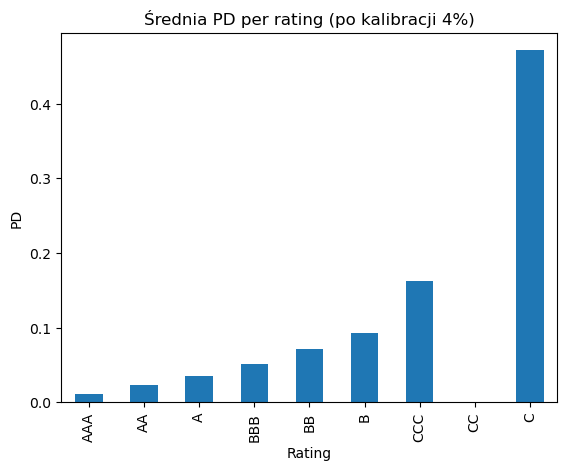

####################
Skalibrowany XGBoost
Znalezione progi ratingowe przy pomocy KMeans:
rating_bins = [0.0, 0.0137, 0.0261, 0.0404, 0.0541, 0.0711, 0.0931, 0.1094, 0.1276, 1.01]


,Count,Mean_PD,Min_PD,Max_PD
Rating,,,,
AAA,197,0.008378,0.006015,0.013677
AA,112,0.019273,0.013971,0.026075
A,70,0.032941,0.026141,0.040350
BBB,63,0.047966,0.040520,0.054057
BB,55,0.060900,0.054804,0.071093
B,26,0.085253,0.071149,0.093099
CCC,31,0.100965,0.094759,0.109392
CC,20,0.119151,0.110725,0.124529
C,26,0.141810,0.127605,0.153784


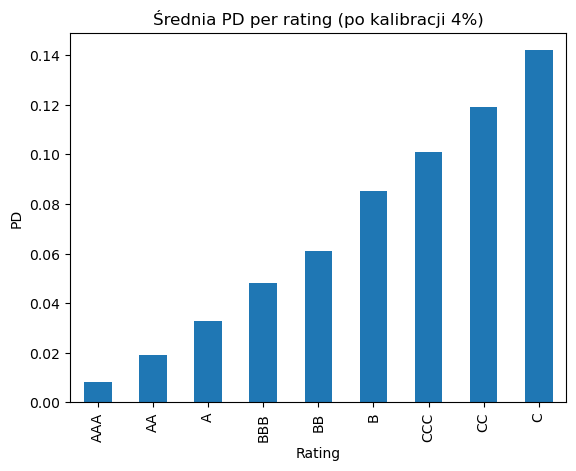

In [42]:
import pickle
rating_labels = ["AAA","AA","A", "BBB","BB","B", "CCC", "CC", "C"]

all_ratings = {}
all_ratings["labels"] = rating_labels
def pd_to_rating(p, rating_bins):
    return pd.cut(p, bins=rating_bins, labels=rating_labels, right=False, include_lowest=True)

short_names = ['CLR', 'CXGB']

for model, name, p, short_name in zip(calibrated_models, calibrated_model_names, probs_cal, short_names):
    print('#'*20)
    print(name)
    my_bins = get_optimal_rating_bins(p, n_classes=len(rating_labels))
    all_ratings[short_name] = my_bins
    print("Znalezione progi ratingowe przy pomocy KMeans:")
    print(f"rating_bins = {my_bins}")
    ratings = pd_to_rating(p, my_bins)
    
    df_temp = pd.DataFrame({
        'PD': p,
        'Rating': ratings
    })
    rating_table = df_temp.groupby('Rating', observed=False).agg(
        Count=('Rating', 'count'),
        Mean_PD=('PD', 'mean'),
        Min_PD=('PD', 'min'),
        Max_PD=('PD', 'max') 
    )
    display(rating_table)
    
    plt.figure()
    rating_table['Mean_PD'].plot(kind='bar')
    plt.title("Średnia PD per rating (po kalibracji 4%)")
    plt.xlabel("Rating")
    plt.ylabel("PD")
    plt.show()

with open(r'models/raitings.pkl', 'wb') as f:
    pickle.dump(all_ratings, f)

## Tabele decyzyjne i przykład wpływu progu na wyniki biznesowe

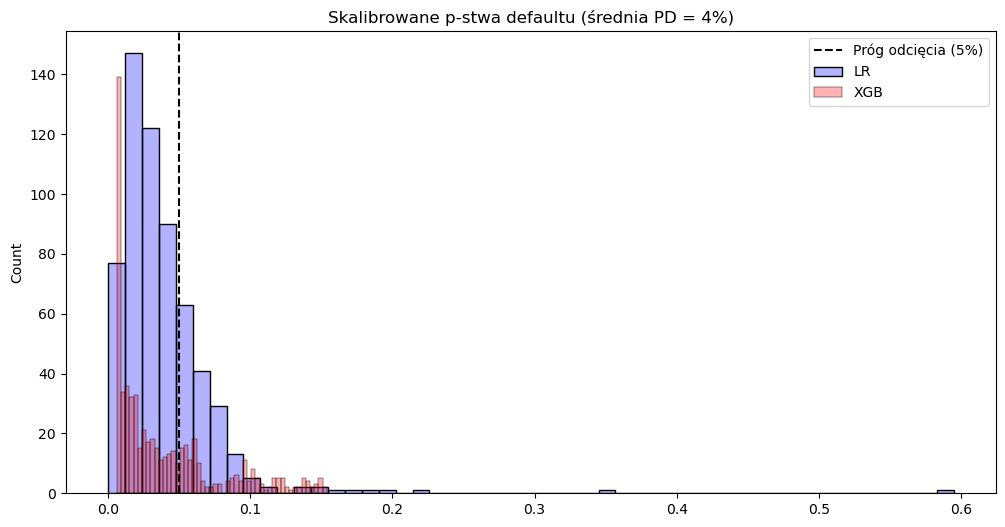

In [43]:
plt.figure(figsize=(12, 6))
sns.histplot(p_test_CLR, color='blue', alpha=0.3, label='LR', bins=50)
sns.histplot(p_test_CXGB, color='red', alpha=0.3, label='XGB', bins=50)
plt.axvline(0.05, color='black', linestyle='--', label='Próg odcięcia (5%)')
plt.title("Skalibrowane p-stwa defaultu (średnia PD = 4%)")
plt.legend()
plt.show()

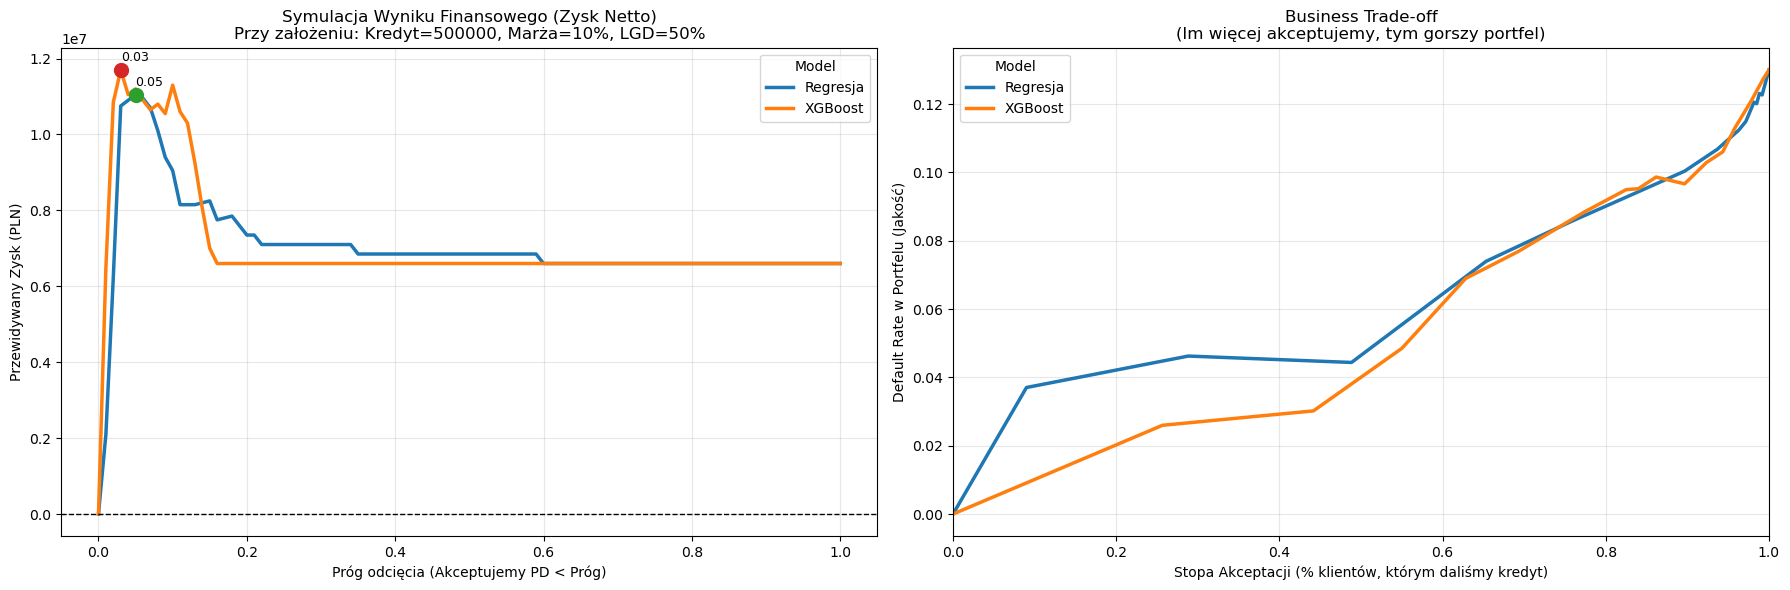

=== REKOMENDACJE BIZNESOWE ===
Model: Regresja
  -> Optymalny próg (Cut-off): PD < 5.00%
  -> Przewidywany Zysk: 11,050,000 PLN
  -> Stopa Akceptacji: 75.8%
  -> Default Rate w portfelu: 8.57%
------------------------------
Model: XGBoost
  -> Optymalny próg (Cut-off): PD < 3.00%
  -> Przewidywany Zysk: 11,700,000 PLN
  -> Stopa Akceptacji: 55.0%
  -> Default Rate w portfelu: 4.85%
------------------------------


In [44]:
# ==========================================
# 1. KONFIGURACJA BIZNESOWA (Dla Firm / SME)
# ==========================================

# Średnia ekspozycja (EAD). 
# Dla małych firm (SME) to często 300k - 500k PLN. Dla dużych to miliony.
# Przyjmijmy bezpiecznie pół miliona.
LOAN_AMOUNT = 500000       

# Marża odsetkowa netto (Net Interest Margin).
# Firmy negocjują! Nie dostaniesz 15%. 
# Realna marża banku na kredycie firmowym to zazwyczaj 2% - 5% ponad WIBOR.
INTEREST_RATE = 0.1       # 4% zarobku na czysto

# Loss Given Default (LGD).
# Firmy często mają zabezpieczenia (hipoteka, maszyny, zapasy).
# Standard regulacyjny (Basel) dla firm bez zabezpieczeń to 45%.
# Jeśli windykacja jest trudna, może być wyższe. Przyjmijmy 45%.
LGD = 0.5


def calculate_business_metrics(y_true, y_proba, thresholds):
    """
    Symuluje wyniki biznesowe dla różnych progów odcięcia.
    """
    results = []
    
    # Całkowita liczba wniosków
    n_total = len(y_true)
    
    for thr in thresholds:
        # Decyzja: 1 (Default) jeśli proba >= thr. 
        # Ale uwaga: Akceptujemy tych, którzy mają ryzyko PONIŻEJ progu.
        # Więc: Accepted = (y_proba < thr)
        
        accepted_mask = y_proba < thr
        n_accepted = np.sum(accepted_mask)
        
        # Jeśli nikogo nie zaakceptowaliśmy, wyniki to 0
        if n_accepted == 0:
            results.append({
                'threshold': thr,
                'acceptance_rate': 0.0,
                'default_rate_portfolio': 0.0,
                'revenue': 0,
                'loss': 0,
                'net_profit': 0
            })
            continue
            
        # Wyciągamy prawdziwe klasy dla zaakceptowanych
        accepted_true_y = y_true[accepted_mask]
        
        # Liczba dobrych i złych w portfelu
        n_defaults = np.sum(accepted_true_y == 1)
        n_goods = n_accepted - n_defaults
        
        # --- KALKULACJA FINANSOWA ---
        # Przychód: Zarabiamy tylko na dobrych, którzy spłacają
        revenue = n_goods * LOAN_AMOUNT * INTEREST_RATE
        
        # Strata: Tracimy na defaultach (część kwoty)
        loss = n_defaults * LOAN_AMOUNT * LGD
        
        # Zysk netto
        net_profit = revenue - loss
        
        # Wskaźniki
        acceptance_rate = n_accepted / n_total
        default_rate_portfolio = n_defaults / n_accepted
        
        results.append({
            'threshold': thr,
            'acceptance_rate': acceptance_rate,
            'default_rate_portfolio': default_rate_portfolio,
            'revenue': revenue,
            'loss': loss,
            'net_profit': net_profit
        })
        
    return pd.DataFrame(results)

# Słownik predykcji
models_preds = {
    'Regresja': p_test_CLR,
    'XGBoost': p_test_CXGB
}

# ==========================================
# 2. URUCHOMIENIE SYMULACJI
# ==========================================
thresholds_range = np.linspace(0.0, 1.0, 101) # Progi co 1%
all_results = pd.DataFrame()

# Pętla po modelach
for model_name, preds in models_preds.items():
    df_res = calculate_business_metrics(y_test, preds, thresholds_range)
    df_res['Model'] = model_name
    all_results = pd.concat([all_results, df_res])

# ==========================================
# 3. WIZUALIZACJA
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# WYKRES 1: Krzywa Zysku (Net Profit vs Threshold)
sns.lineplot(data=all_results, x='threshold', y='net_profit', hue='Model', ax=axes[0], linewidth=2.5)
axes[0].set_title(f'Symulacja Wyniku Finansowego (Zysk Netto)\nPrzy założeniu: Kredyt={LOAN_AMOUNT}, Marża={INTEREST_RATE:.0%}, LGD={LGD:.0%}')
axes[0].set_ylabel('Przewidywany Zysk (PLN)')
axes[0].set_xlabel('Próg odcięcia (Akceptujemy PD < Próg)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1) # Linia zero

# Zaznaczamy MAX profit dla każdego modelu
for model in all_results['Model'].unique():
    subset = all_results[all_results['Model'] == model]
    max_profit = subset['net_profit'].max()
    best_thr = subset.loc[subset['net_profit'].idxmax(), 'threshold']
    axes[0].plot(best_thr, max_profit, 'o', markersize=10) # Kropka w maximum
    axes[0].text(best_thr, max_profit*1.02, f'{best_thr:.2f}', fontsize=9)

# WYKRES 2: Trade-off (Acceptance Rate vs Default Rate)
# To pokazuje jakość portfela
sns.lineplot(data=all_results, x='acceptance_rate', y='default_rate_portfolio', hue='Model', ax=axes[1], linewidth=2.5)
axes[1].set_title('Business Trade-off\n(Im więcej akceptujemy, tym gorszy portfel)')
axes[1].set_xlabel('Stopa Akceptacji (% klientów, którym daliśmy kredyt)')
axes[1].set_ylabel('Default Rate w Portfelu (Jakość)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Wypisanie najlepszych progów w konsoli
print("=== REKOMENDACJE BIZNESOWE ===")
for model in all_results['Model'].unique():
    subset = all_results[all_results['Model'] == model]
    best_row = subset.loc[subset['net_profit'].idxmax()]
    print(f"Model: {model}")
    print(f"  -> Optymalny próg (Cut-off): PD < {best_row['threshold']:.2%}")
    print(f"  -> Przewidywany Zysk: {best_row['net_profit']:,.0f} PLN")
    print(f"  -> Stopa Akceptacji: {best_row['acceptance_rate']:.1%}")
    print(f"  -> Default Rate w portfelu: {best_row['default_rate_portfolio']:.2%}")
    print("-" * 30)